In [28]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # Only errors are logged
os.environ['TF_GPU_ALLOCATOR'] ='cuda_malloc_async'

import keras
from keras import layers
import numpy as np
import os
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf

from keras import models
from IPython import display
import scipy.io.wavfile

import pandas as pd
from scipy.signal import resample

keras.utils.set_random_seed(41)

In [29]:
BASE_DATA_DIR = "./datasets/"
BATCH_SIZE = 16
NUM_CLASSES = 8
EPOCHS = 50
SAMPLE_RATE = 48000

In [30]:
train_ds, val_ds = tf.keras.utils.audio_dataset_from_directory(
    directory='datasets',
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    seed=41,
    output_sequence_length=None,
    label_mode = 'int',
    subset='both')

label_names = np.array(train_ds.class_names)
print()
print("label names:", label_names)


Found 4240 files belonging to 8 classes.
Using 3392 files for training.
Using 848 files for validation.

label names: ['angry' 'calm' 'disgust' 'fear' 'happy' 'neutral' 'sad' 'surprised']


In [31]:
test_ds = val_ds.shard(num_shards=2, index=0)
val_ds = val_ds.shard(num_shards=2, index=1)


In [32]:
def plot_single_spectrogram(sample_wav_data):
    spectrogram = layers.STFTSpectrogram(
        mode="log",
        frame_length=SAMPLE_RATE * 20 // 1000,
        frame_step=SAMPLE_RATE * 5 // 1000,
        fft_length=1024,
        trainable=False,
    # )(sample_wav_data[None, ...])[0, ...]
    )(sample_wav_data)[0,...]

    # Plot the spectrogram
    plt.imshow(spectrogram, origin="lower")
    plt.title("Single Channel Spectrogram")
    plt.xlabel("Time")
    plt.ylabel("Frequency")
    plt.show()

In [33]:
for t in train_ds.take(1):
    print(t[0].shape)
    print(t[0][0])
    # plot_single_spectrogram(t[0])

(16, 57658, 1)
tf.Tensor(
[[0.]
 [0.]
 [0.]
 ...
 [0.]
 [0.]
 [0.]], shape=(57658, 1), dtype=float32)


In [34]:
stftlayer = layers.STFTSpectrogram(
            mode="log",
            frame_length=SAMPLE_RATE * 40 // 1000,
            frame_step=SAMPLE_RATE * 15 // 1000,
            trainable=False,
        )

In [ ]:
keras.backend.clear_session(free_memory=True)
model1d = keras.Sequential(
    [
        layers.InputLayer((None,1)),
        stftlayer,
        # layers.Conv1D(64, 8, activation="relu"),
        # layers.Conv1D(128, 16, activation="relu"),
        # layers.LayerNormalization(),
        # layers.MaxPooling1D(4),
        # layers.Conv1D(128, 8, activation="relu"),
        # layers.Conv1D(256, 8, activation="relu"),
        # layers.Conv1D(512, 4, activation="relu"),
        # layers.LayerNormalization(),
        # layers.Dropout(0.5),
        layers.GlobalMaxPooling1D(),
        # layers.Dense(256, activation="relu"),
        # layers.Dense(256, activation="relu"),
        # layers.Dropout(0.5),
        # layers.Flatten(),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ],
    name="model_1d_non_trainble_stft",
)
model1d.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model1d.summary()

Model: "model_1d_non_trainble_stft"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ stft_spectrogram_4              │ (None, None, 1025)     │     3,936,000 │
│ (STFTSpectrogram)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 1025)           │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │         8,208 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,944,208 (15.05 MB)

 Trainable params: 8,208 (32.06 KB)

 Non-trainable params: 3,936,000 (15.01 MB)

In [42]:
history_model1d = model1d.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
        )
    ],
)

Epoch 1/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 31s 141ms/step - accuracy: 0.0713 - loss: 4.2699 - val_accuracy: 0.0817 - val_loss: 3.1623
Epoch 2/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.0985 - loss: 2.9794 - val_accuracy: 0.0986 - val_loss: 2.9451
Epoch 3/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.1138 - loss: 2.8417 - val_accuracy: 0.1274 - val_loss: 2.8184
Epoch 4/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1306 - loss: 2.7213 - val_accuracy: 0.1346 - val_loss: 2.7108
Epoch 5/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.1436 - loss: 2.6136 - val_accuracy: 0.1562 - val_loss: 2.6166
Epoch 6/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1580 - loss: 2.5134 - val_accuracy: 0.1514 - val_loss: 2.5300
Epoch 7/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1719 - loss: 2.4258 - val_accuracy: 0.1731 - val_loss: 2.4558
Epoch 8/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1840 - loss: 2.3459 - val_accuracy

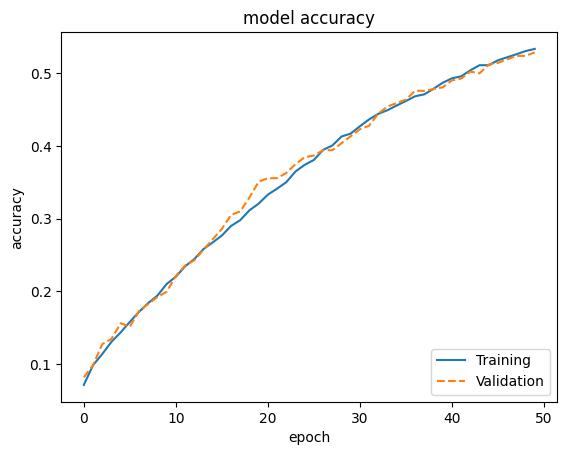

In [43]:
plt.plot(history_model1d.history['accuracy'])
plt.plot(history_model1d.history['val_accuracy'],linestyle='--')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()

In [44]:
keras.backend.clear_session(free_memory=True)
model1d = keras.Sequential(
    [
        layers.InputLayer((None,1)),
        stftlayer,
        layers.Conv1D(64, 8, activation="relu"),
        layers.Conv1D(128, 16, activation="relu"),
        layers.LayerNormalization(),
        layers.MaxPooling1D(4),
        # layers.Conv1D(128, 8, activation="relu"),
        # layers.Conv1D(256, 8, activation="relu"),
        # layers.Conv1D(512, 4, activation="relu"),
        # layers.LayerNormalization(),
        # layers.Dropout(0.5),
        layers.GlobalMaxPooling1D(),
        # layers.Dense(256, activation="relu"),
        # layers.Dense(256, activation="relu"),
        # layers.Dropout(0.5),
        # layers.Flatten(),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ],
    name="model_1d_non_trainble_stft",
)
model1d.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model1d.summary()

Model: "model_1d_non_trainble_stft"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ stft_spectrogram_4              │ (None, None, 1025)     │     3,936,000 │
│ (STFTSpectrogram)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, None, 64)       │       524,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, None, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, None, 128)      │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, None, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,593,352 (17.52 MB)

 Trainable params: 657,352 (2.51 MB)

 Non-trainable params: 3,936,000 (15.01 MB)

In [45]:
history_model1d = model1d.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
        )
    ],
)

Epoch 1/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 69s 317ms/step - accuracy: 0.2188 - loss: 2.0222 - val_accuracy: 0.1514 - val_loss: 1.9474
Epoch 2/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.3402 - loss: 1.7977 - val_accuracy: 0.4159 - val_loss: 1.6703
Epoch 3/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4664 - loss: 1.5366 - val_accuracy: 0.5649 - val_loss: 1.3425
Epoch 4/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5740 - loss: 1.2761 - val_accuracy: 0.5986 - val_loss: 1.2493
Epoch 5/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.6557 - loss: 1.0644 - val_accuracy: 0.6346 - val_loss: 1.0015
Epoch 6/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7049 - loss: 0.9379 - val_accuracy: 0.7212 - val_loss: 0.9034
Epoch 7/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.7311 - loss: 0.8706 - val_accuracy: 0.6995 - val_loss: 0.8664
Epoch 8/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7361 - loss: 0.8148 - val_accu

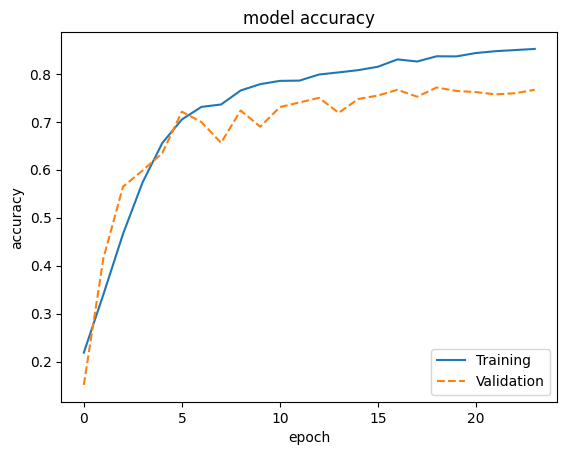

In [46]:
plt.plot(history_model1d.history['accuracy'])
plt.plot(history_model1d.history['val_accuracy'],linestyle='--')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()

In [65]:
keras.backend.clear_session(free_memory=True)
model1d = keras.Sequential(
    [
        layers.InputLayer((None,1)),
        stftlayer,
        layers.Conv1D(64, 8, activation="relu"),
        layers.Conv1D(128, 16, activation="relu"),
        layers.LayerNormalization(),
        # layers.MaxPooling1D(4),
        layers.Conv1D(128, 8, activation="relu"),
        layers.Conv1D(256, 16, padding='same', activation="relu"),
        layers.Conv1D(512, 64, padding='same', activation="relu"),
        layers.LayerNormalization(),
        layers.MaxPooling1D(4),        
        # layers.LayerNormalization(),
        layers.Dropout(0.5),
        layers.GlobalMaxPooling1D(),
        layers.Dense(256, activation="relu", kernel_regularizer=keras.regularizers.L1L2(l1=1e-5, l2=1e-4)),
        layers.Dense(512, activation="relu", kernel_regularizer=keras.regularizers.L1L2(l1=1e-5, l2=1e-4)),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ],
    name="model_1d_non_trainble_stft",
)
model1d.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model1d.summary()

Model: "model_1d_non_trainble_stft"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ stft_spectrogram_4              │ (None, None, 1025)     │     3,936,000 │
│ (STFTSpectrogram)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, None, 64)       │       524,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, None, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, None, 128)      │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, None, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, None, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, None, 512)      │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, None, 512)      │         1,024 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, None, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, None, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 512)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │         4,104 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,905,224 (53.04 MB)

 Trainable params: 9,969,224 (38.03 MB)

 Non-trainable params: 3,936,000 (15.01 MB)

In [66]:
history_model1d = model1d.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
        )
    ],
)

Epoch 1/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 218s 1s/step - accuracy: 0.1406 - loss: 2.4516 - val_accuracy: 0.1130 - val_loss: 2.2208
Epoch 2/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - accuracy: 0.2182 - loss: 2.1601 - val_accuracy: 0.2644 - val_loss: 2.1196
Epoch 3/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.3715 - loss: 1.8487 - val_accuracy: 0.4976 - val_loss: 1.7212
Epoch 4/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.5174 - loss: 1.4936 - val_accuracy: 0.5168 - val_loss: 1.4717
Epoch 5/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - accuracy: 0.5929 - loss: 1.2747 - val_accuracy: 0.7043 - val_loss: 1.2279
Epoch 6/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.6781 - loss: 1.0706 - val_accuracy: 0.7332 - val_loss: 1.0015
Epoch 7/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.7190 - loss: 0.9755 - val_accuracy: 0.7163 - val_loss: 0.9690
Epoch 8/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.7353 - loss: 0.8947 - val_ac

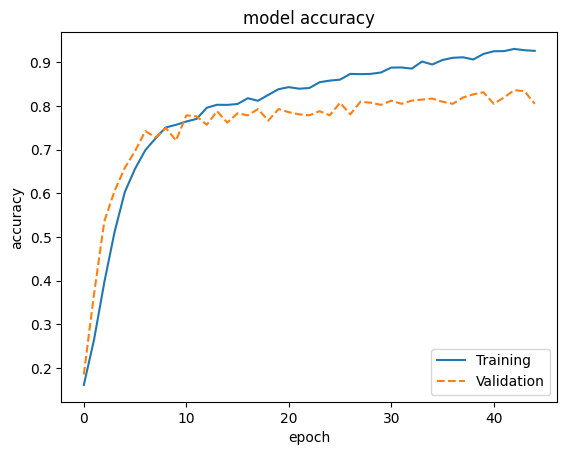

In [64]:
plt.plot(history_model1d.history['accuracy'])
plt.plot(history_model1d.history['val_accuracy'],linestyle='--')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()

In [67]:
keras.backend.clear_session(free_memory=True)
model1d = keras.Sequential(
    [
        layers.InputLayer((None,1)),
        stftlayer,
        layers.Conv1D(64, 8, activation="relu"),
        layers.Conv1D(128, 16, activation="relu"),
        layers.LayerNormalization(),
        # layers.MaxPooling1D(4),
        layers.Conv1D(128, 8, activation="relu"),
        layers.Conv1D(256, 16, padding='same', activation="relu"),
        layers.Conv1D(512, 64, padding='same', activation="relu"),
        layers.LayerNormalization(),
        layers.MaxPooling1D(4),        
        # layers.LayerNormalization(),
        layers.Dropout(0.5),
        layers.GlobalMaxPooling1D(),
        layers.Dense(256, activation="relu", kernel_regularizer=keras.regularizers.L1L2(l1=1e-4, l2=1e-3)),
        layers.Dense(512, activation="relu", kernel_regularizer=keras.regularizers.L1L2(l1=1e-4, l2=1e-3)),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ],
    name="model_1d_non_trainble_stft",
)
model1d.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model1d.summary()

Model: "model_1d_non_trainble_stft"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ stft_spectrogram_4              │ (None, None, 1025)     │     3,936,000 │
│ (STFTSpectrogram)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, None, 64)       │       524,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, None, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, None, 128)      │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, None, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, None, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, None, 512)      │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, None, 512)      │         1,024 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, None, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, None, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 512)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │         4,104 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,905,224 (53.04 MB)

 Trainable params: 9,969,224 (38.03 MB)

 Non-trainable params: 3,936,000 (15.01 MB)

In [68]:
history_model1d = model1d.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
        )
    ],
)

Epoch 1/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 199s 920ms/step - accuracy: 0.1636 - loss: 4.0570 - val_accuracy: 0.1322 - val_loss: 3.8501
Epoch 2/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 14s 67ms/step - accuracy: 0.2341 - loss: 3.7474 - val_accuracy: 0.2644 - val_loss: 3.6832
Epoch 3/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3847 - loss: 3.4038 - val_accuracy: 0.4712 - val_loss: 3.3279
Epoch 4/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.4965 - loss: 3.0815 - val_accuracy: 0.6106 - val_loss: 2.9472
Epoch 5/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.6073 - loss: 2.7964 - val_accuracy: 0.6731 - val_loss: 2.7355
Epoch 6/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6621 - loss: 2.5895 - val_accuracy: 0.7476 - val_loss: 2.5000
Epoch 7/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.7049 - loss: 2.4573 - val_accuracy: 0.7596 - val_loss: 2.4082
Epoch 8/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - accuracy: 0.7391 - loss: 2.3679 - val_a

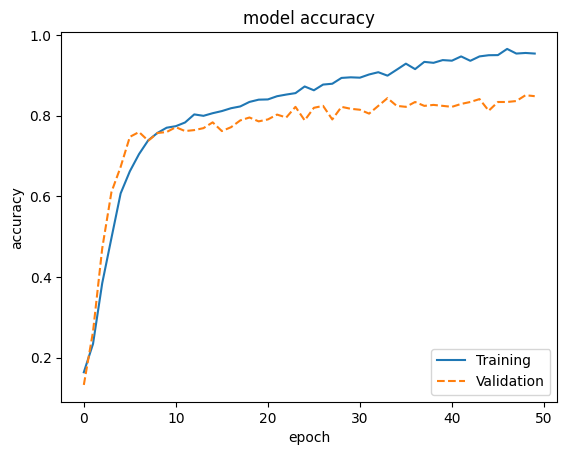

In [69]:
plt.plot(history_model1d.history['accuracy'])
plt.plot(history_model1d.history['val_accuracy'],linestyle='--')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()